# Meta 2 ECAC - Testing Feature Selection Methods

In [25]:
# Importation of all Frameworks and Tools needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from skrebate import ReliefF
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from scipy import stats
from scipy.stats import skew, kurtosis, iqr
from scipy.signal import welch
from scipy.fft import rfft, rfftfreq
from scipy.interpolate import interp1d
from typing import Counter


Importing Feature Dataset obtained in meta1 and altering it so it contains participant id 

In [2]:
# Importing the dataset and filtering activities
df = pd.read_csv('feature_set.csv')
df_filtered = df[df["Activity"].isin(range(1, 8))].copy()
print(f"Filtered dataset shape: {df_filtered.shape}")
print(f"Unique activities after filtering: {df_filtered['Activity'].unique()}")



Filtered dataset shape: (1405, 179)
Unique activities after filtering: [1 2 3 4 5 6 7]


Repeating the same feature extraction principals from first meta 

In [20]:

def dominant_frequency(signal, fs):
    n = len(signal)
    if n == 0: return 0
    yf = np.abs(rfft(signal))
    xf = rfftfreq(n, d=1/fs)
    dominant_idx = np.argmax(yf[1:]) + 1
    if dominant_idx >= len(xf): return 0
    return xf[dominant_idx]

def spectral_entropy(signal, fs):
    freqs, psd = welch(signal, fs=fs)
    psd_sum = np.sum(psd)
    if psd_sum == 0: return 0
    psd_norm = psd / psd_sum
    entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
    return entropy

def zero_crossing_rate(signal):
    return np.sum(np.diff(np.sign(signal)) != 0) / len(signal)

def mean_crossing_rate(signal):
    mean_val = np.mean(signal)
    centered = signal - mean_val
    return np.sum(np.diff(np.sign(centered)) != 0) / len(signal)

def extract_statistical_features(signal, fs):
    signal = signal.astype(float)
    return [
        np.mean(signal), np.median(signal), np.std(signal), np.var(signal),
        np.sqrt(np.mean(signal**2)), np.mean(np.diff(signal)),
        skew(signal), kurtosis(signal), iqr(signal),
        zero_crossing_rate(signal), mean_crossing_rate(signal),
        spectral_entropy(signal, fs),
    ]

def extract_correlations(window):
    features = []
    axes = window.shape[1]
    for i in range(axes):
        for j in range(i + 1, axes):
            if np.std(window[:, i]) == 0 or np.std(window[:, j]) == 0:
                features.append(0)
            else:
                features.append(np.corrcoef(window[:, i], window[:, j])[0, 1])
    return features

def extract_feature_vector(window, fs):
    features = []
    # Statistical features
    for i in range(window.shape[1]):
        features.extend(extract_statistical_features(window[:, i], fs))
    features.extend(extract_correlations(window))
    return np.array(features)

def sliding_windows(data, labels, window_sec=5, overlap=0.5, fs=50):
    window_size = int(window_sec * fs)
    if window_size < 1: window_size = 1
    step_size = int(window_size * (1 - overlap))
    if step_size < 1: step_size = 1
    for start in range(0, len(data) - window_size + 1, step_size):
        end = start + window_size
        window = data[start:end]
        label_segment = labels[start:end]
        if np.all(label_segment == label_segment[0]):
            yield window, label_segment[0]


def generate_features_from_df(df):
    """
    Takes a dataframe, estimates sampling rate, and extracts features.
    """
    print("Extracting features from subset...")
    
    # Estimate FS
    diffs = df["Timestamp"].diff()
    avg_diff = diffs[diffs > 0].median()
    
    if avg_diff > 1:
        fs = 1000.0 / avg_diff
    elif avg_diff > 0:
        fs = 1.0 / avg_diff
    else:
        fs = 50.0
        
    print(f"  - Sampling Rate: {fs:.2f} Hz")
    
    data_cols = ["Acc_x","Acc_y","Acc_z","Gyro_x","Gyro_y","Gyro_z","Mag_x","Mag_y","Mag_z"]
    data = df[data_cols].values
    labels = df["Activity"].values
    
    X_list = []
    y_list = []
    
    count = 0
    for window, label in sliding_windows(data, labels, fs=fs):
        feat = extract_feature_vector(window, fs)
        X_list.append(feat)
        y_list.append(label)
        count += 1
        
    print(f"  - Extracted {count} windows.")
    
    if count == 0:
        return pd.DataFrame()

    X = np.array(X_list)
    y = np.array(y_list)
    
    feat_cols = [f"Feature_{i}" for i in range(X.shape[1])]
    df_feats = pd.DataFrame(X, columns=feat_cols)
    df_feats["Activity"] = y
    
    return df_feats.dropna()

def generate_synthetic_samples(X, y, target_activity, n_new_samples=3):
    print(f"Generating {n_new_samples} synthetic samples for Activity {target_activity}...")
    current_count = np.sum(y == target_activity)
    
    if current_count < 2:
        print("Error: Not enough samples to use SMOTE.")
        return None, None, None
        
    strategy = {target_activity: current_count + n_new_samples}
    k = min(current_count - 1, 5)
    smote = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=42)
    
    X_res, y_res = smote.fit_resample(X, y)
    
    if not isinstance(X_res, pd.DataFrame):X_res = pd.DataFrame(X_res, columns=X.columns)

    n_synthetic = len(X_res) - len(X)
    X_synthetic = X_res.iloc[-n_synthetic:]
    y_synthetic = y_res.iloc[-n_synthetic:]
    
    return X_res, y_res, X_synthetic

Importing the Raw dataset (so we can have access to each participant activity)

In [ ]:

# ==========================================
# 1. UPDATED Data Loading (Loads EVERYTHING)
# ==========================================

def load_full_raw_dataset():
    """
    Loads raw data for ALL participants (0-14) and ALL devices (1-5).
    Adds a 'Participant' column to distinguish them.
    """
    df_list = []

    # Iterate through all participants (0 to 14)
    for part in range(15):
        print(f"Loading data for Participant {part}...")
        for device in range(1, 6):
            url = f"https://raw.githubusercontent.com/spl-icsforth/FORTH_TRACE_DATASET/master/part{part}/part{part}dev{device}.csv"
            try:
                cols = ["DeviceId", "Acc_x", "Acc_y", "Acc_z",
                        "Gyro_x", "Gyro_y", "Gyro_z",
                        "Mag_x", "Mag_y", "Mag_z",
                        "Timestamp", "Activity"]
                temp_df = pd.read_csv(url, header=None, names=cols)
                temp_df["Participant"] = part
                df_list.append(temp_df)
            except Exception as e:
                print(f"  - Error loading Part {part} Device {device}: {e}")
    # Combine everything into one massive DataFrame
    print("Concatenating all datasets...")
    full_df = pd.concat(df_list, axis=0, ignore_index=True)
    print(f"DONE. Total Raw Shape: {full_df.shape}")
    return full_df



Checking whether the dataset is balanced or not 

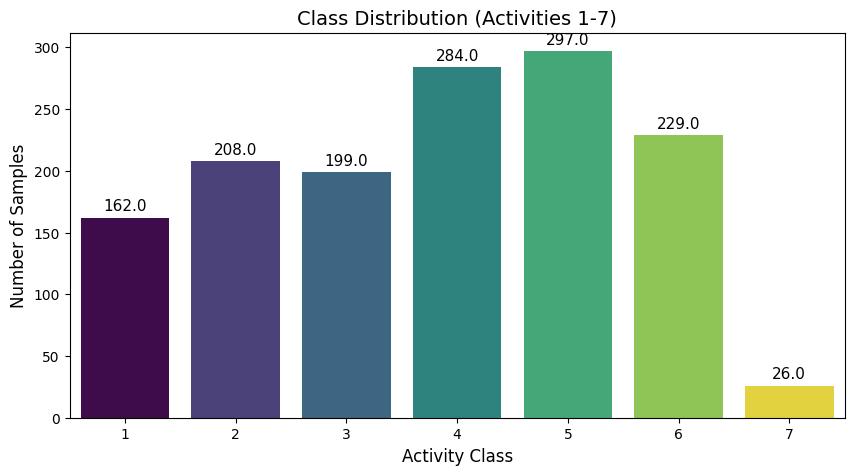


--- Exact Counts per Activity ---
Activity
1    162
2    208
3    199
4    284
5    297
6    229
7     26
Name: count, dtype: int64

Imbalance Ratio (Max/Min): 11.42


In [ ]:
# Extract Labels (y)
y = df_filtered['Activity'].values
plt.figure(figsize=(10, 5))
# Use seaborn to plot count of each activity
ax = sns.countplot(x=y, hue=y,  palette="viridis" , legend=False)
plt.title('Class Distribution (Activities 1-7)', fontsize=14)
plt.xlabel('Activity Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()
print("\n--- Exact Counts per Activity ---")
print(df_filtered['Activity'].value_counts().sort_index())

# Check for Imbalance
counts = df_filtered['Activity'].value_counts()
min_count = counts.min()
max_count = counts.max()
imbalance_ratio = max_count / min_count

print(f"\nImbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

1.2 Defining a SMOTE Function

In [ ]:
def generate_synthetic_samples(X, y, target_activity, n_new_samples=3):
    print(f"Generating {n_new_samples} synthetic samples for Activity {target_activity}...")
    current_count = np.sum(y == target_activity)
    
    if current_count < 2:
        print("Error: Not enough samples to use SMOTE.")
        return None, None, None
        
    strategy = {target_activity: current_count + n_new_samples}
    k = min(current_count - 1, 5)
    smote = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=42)
    X_res, y_res = smote.fit_resample(X, y)
    if not isinstance(X_res, pd.DataFrame):X_res = pd.DataFrame(X_res, columns=X.columns)
    n_synthetic = len(X_res) - len(X)
    X_synthetic = X_res.iloc[-n_synthetic:]
    y_synthetic = y_res.iloc[-n_synthetic:]
    
    return X_res, y_res, X_synthetic

1.3 Applying the SMOTE function

Loading data for Participant 0...
Loading data for Participant 1...
Loading data for Participant 2...
Loading data for Participant 3...
Loading data for Participant 4...
Loading data for Participant 5...
Loading data for Participant 6...
Loading data for Participant 7...
Loading data for Participant 8...
Loading data for Participant 9...
Loading data for Participant 10...
Loading data for Participant 11...
Loading data for Participant 12...
Loading data for Participant 13...
Loading data for Participant 14...
Concatenating all datasets...
DONE. Total Raw Shape: (3930873, 13)

--- Processing Participant 3 ---
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 1898 windows.
Generating 3 synthetic samples for Activity 4...


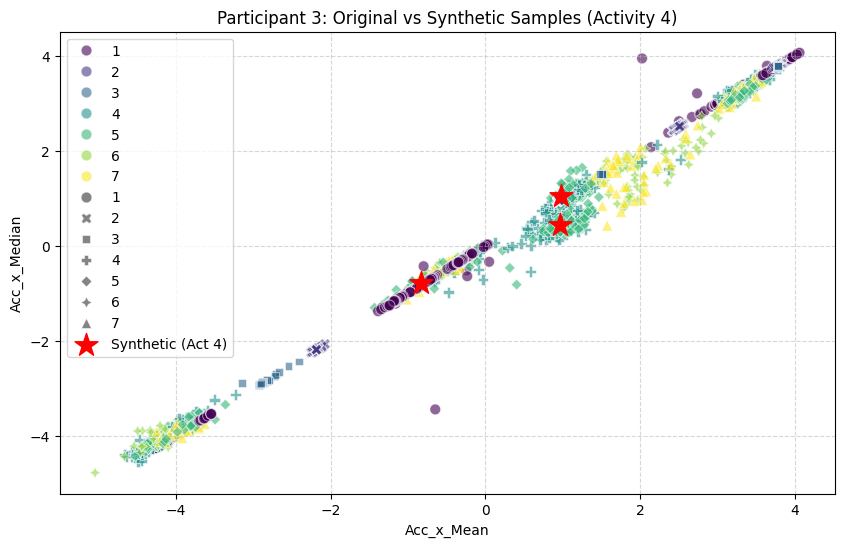

In [ ]:
# Load the ENTIRE raw dataset (Once)
# -------------------------------------
if 'df_all_raw' not in locals(): # check if already loaded to save time in notebooks
    df_all_raw = load_full_raw_dataset()
else:
    print("Dataset already loaded. Skipping download.")

# Filter for Participant 3 ONLY
# --------------------------------
print("\n--- Processing Participant 3 ---")
df_part3_raw = df_all_raw[df_all_raw["Participant"] == 3].copy()

if df_part3_raw.empty:
    print("Error: No data found for Participant 3.")
else:
    # Generate Features for Part 3
    df_features_p3 = generate_features_from_df(df_part3_raw)
    axes_names = ["Acc_x", "Acc_y", "Acc_z", "Gyro_x", "Gyro_y", "Gyro_z", "Mag_x", "Mag_y", "Mag_z"]
    stat_names = ["Mean", "Median", "Std", "Var", "RMS", "MeanDiff", "Skew", "Kurtosis", "IQR", "ZCR", "MCR", "SpecEnt"]
    feature_names = []
    
    # Add Statistical Feature Names
    for ax in axes_names:
        for stat in stat_names:
            feature_names.append(f"{ax}_{stat}")
            
    # Add Correlation Feature Names
    for i in range(len(axes_names)):
        for j in range(i + 1, len(axes_names)):
            feature_names.append(f"Corr_{axes_names[i]}_{axes_names[j]}")
            
    # Apply names to the DataFrame (preserving the 'Activity' column at the end)
    if df_features_p3.shape[1] == len(feature_names) + 1:
        df_features_p3.columns = feature_names + ["Activity"]
    else:
        print(f"Warning: Name mismatch. Generated {len(feature_names)} names for {df_features_p3.shape[1]-1} features.")
    # ------------------------------------------
    df_features_p3 = df_features_p3[df_features_p3["Activity"] <= 7]
    # Prepare for SMOTE (Target: Activity 4)
    target_act = 4
    X = df_features_p3.drop(columns=["Activity"])
    y = df_features_p3["Activity"]
    # Run SMOTE
    X_resampled, y_resampled, X_syn = generate_synthetic_samples(X, y, target_act, n_new_samples=3)
    # Visualization
    if X_syn is not None:
        feat_x = X.columns[0]
        feat_y = X.columns[1]
        
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=df_features_p3,
            x=feat_x,
            y=feat_y,
            hue="Activity",
            style="Activity",
            palette="viridis",
            alpha=0.6,
            s=60
        )
        plt.scatter(
            X_syn[feat_x],
            X_syn[feat_y],
            color='red',
            marker='*',
            s=300,
            label='Synthetic (Act 4)',
            zorder=10
        )
        
        plt.title(f"Participant 3: Original vs Synthetic Samples (Activity {target_act})")
        plt.xlabel(feat_x)
        plt.ylabel(feat_y)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

2.1 Extracting features using Embedding

In [ ]:
# ==========================================
# 1. EXACT FUNCTIONS FROM embeddings_extractor.py
# ==========================================

def load_model():
    ''' Loads the model from the github repo and obtains just the feature encoder. '''
    
    print("Loading Harnet5 model...")
    repo = 'OxWearables/ssl-wearables'
    # class_num não interessa para extrair features; mas o hub pede este arg
    model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
    model.eval()
    # Passo crucial: ficar só com a parte auto-supervisionada
    feature_encoder = model.feature_extractor
    # Note: The original script forces CPU. We will allow moving to GPU later if needed.
    feature_encoder.to("cpu")
    feature_encoder.eval()
    return feature_encoder

def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
    acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
    fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)
    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])
    return acc_resampled, fs_target

def acc_segmentation(data):
    ''' Estract ACC segments and their activities '''

    TIMESTAMP_COL = 10
    MIN_SEGMENT_SIZE = 20
    fs_in_hz = 51.5 # Unused inside, but kept for strict adherence
    win_size = 5000
    start_time = data[0,TIMESTAMP_COL]
    end_time = start_time + win_size
    activities = []
    segments = []

    while end_time < data[-1,TIMESTAMP_COL]:
        mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

        if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

            acc_xyz = data[mask,1:4]
            activity = data[mask, -1][0]
            
            activities.append(activity)
            segments.append( acc_xyz )
        start_time = end_time - win_size/2
        end_time = start_time + win_size
    return segments, activities

# ==========================================
# 2.GENERATOR (Using the functions above)
# ==========================================
def generate_embeddings_dataset(df_raw):
    feature_encoder = load_model()
    # Optimization: Move to GPU if available (overriding the CPU default in load_model)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    feature_encoder.to(device)
    print(f"Model moved to {device} for processing.")
    # Process Group-by-Group
    grouped = df_raw.groupby(["Participant", "DeviceId"])
    all_embeddings_list = []
    print(f"Processing {len(grouped)} segments...")
    for (part_id, dev_id), group_df in grouped:
        #Estimate Sampling Rate
        diffs = group_df["Timestamp"].diff()
        avg_diff = diffs[diffs > 0].median()
        data_np = group_df.iloc[:, :12].values.copy()
        if avg_diff < 1.0:
            fs = 1.0 / avg_diff
            # Convert Seconds -> Milliseconds for segmentation logic
            data_np[:, 10] = data_np[:, 10] * 1000.0
        else:
            fs = 1000.0 / avg_diff
        # Call the exact function provided
        segments_raw, seg_labels = acc_segmentation(data_np)
        if not segments_raw:
            continue
        # Call the exact function provided for each segment
        segments_resampled = []
        for seg in segments_raw:
            # resample_to_30hz_5s returns (data, fs_target)
            res_seg = resample_to_30hz_5s(seg, fs)[0]
            segments_resampled.append(res_seg)
        # ---EMBEDDING GENERATION ---
        batch_np = np.array(segments_resampled)
        batch_np = np.transpose(batch_np, (0, 2, 1))
        batch_size = 64
        with torch.no_grad():
            for i in range(0, len(batch_np), batch_size):
                chunk_np = batch_np[i : i+batch_size]
                chunk_tensor = torch.from_numpy(chunk_np).float().to(device)
                embeddings = feature_encoder(chunk_tensor)
                emb_np = embeddings.cpu().numpy()
                if emb_np.ndim > 2:
                    emb_np = emb_np.reshape(emb_np.shape[0], -1)
                batch_res = pd.DataFrame(emb_np)
                batch_res["Activity"] = seg_labels[i : i+batch_size]
                batch_res["Participant"] = part_id
                all_embeddings_list.append(batch_res)
    # Finalize
    if not all_embeddings_list:
        return pd.DataFrame()
    final_df = pd.concat(all_embeddings_list, ignore_index=True)
    feat_cols = [c for c in final_df.columns if isinstance(c, int)]
    rename_map = {c: f"Emb_{c}" for c in feat_cols}
    final_df = final_df.rename(columns=rename_map)
    return final_df
# ==========================================
# 3. EXECUTION
# ==========================================
if 'df_all_raw' in locals():
    print("\nGenerating Embeddings (Using exact provided functions)...")
    df_raw_filtered = df_all_raw[df_all_raw["Activity"] <= 7].copy()
    EMBEDDINGS_DATASET = generate_embeddings_dataset(df_raw_filtered)
    print(f"\nDONE. Embeddings Dataset Shape: {EMBEDDINGS_DATASET.shape}")
    print(EMBEDDINGS_DATASET.head())
else:
    print("Error: df_all_raw not loaded.")


Generating Embeddings (Using exact provided functions)...
Loading Harnet5 model...


Using cache found in C:\Users\ramya/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
Model moved to cpu for processing.
Processing 75 segments...

DONE. Embeddings Dataset Shape: (29720, 514)
   Emb_0  Emb_1  Emb_2  Emb_3     Emb_4     Emb_5  Emb_6     Emb_7  Emb_8  \
0    0.0    0.0    0.0    0.0  0.028251  0.052633    0.0  0.043271    0.0   
1    0.0    0.0    0.0    0.0  0.024366  0.047597    0.0  0.052120    0.0   
2    0.0    0.0    0.0    0.0  0.026458  0.053930    0.0  0.049916    0.0   
3    0.0    0.0    0.0    0.0  0.027667  0.050848    0.0  0.043369    0.0   
4    0.0    0.0    0.0    0.0  0.028083  0.044541    0.0  0.047659    0.0   

      Emb_9  ...   Emb_504  Emb_505  Emb_506   Emb_507   Emb_508   Emb_509  \
0  0.043261  ...  0.005634      0.0      0.0  0.009069  0.086691  0.039299   
1  0.038358  ...  0.011343      0.0      0.0  0.009913  0.087089  0.038609   
2  0.041910  ...  0.006098      0.0      0.0  0.010750  0.083309  0.042045   
3  0.043349  ...  0.004550      0.0      0.0  0.009165  0.086541  0.037584   
4  0.039425  ...  0.0

Generating a complementary dataset to the meta 1 in order to keep the Participant ID


In [ ]:
# ==========================================
# REGENERATE FEATURES DATASET (With Participant IDs)
# ==========================================
def create_features_dataset_with_ids(df_raw):
    print("Regenerating Features Dataset to include Participant IDs...")
    # We process each participant separately to assign the correct ID
    grouped = df_raw.groupby(["Participant", "DeviceId"])
    all_features_list = []
    for (part_id, dev_id), group_df in grouped:
        try:
            feats_df = generate_features_from_df(group_df)
            if not feats_df.empty:
                # Tag these rows with the Participant ID
                feats_df["Participant"] = part_id
                all_features_list.append(feats_df)
        except Exception as e:
            continue

    if not all_features_list:
        return pd.DataFrame()
    # Combine everything
    final_df = pd.concat(all_features_list, ignore_index=True)
    return final_df
# ==========================================
# EXECUTION
# ==========================================
if 'df_all_raw' in locals():
    df_raw_filtered = df_all_raw[df_all_raw["Activity"] <= 7].copy()
    FEATURES_DATASET = create_features_dataset_with_ids(df_raw_filtered)
    print("\n--- SUCCESS ---")
    print(f"FEATURES DATASET Shape: {FEATURES_DATASET.shape}")
    print(f"Columns: {list(FEATURES_DATASET.columns[:5])} ... 'Participant'")
else:
    print("Error: 'df_all_raw' is not loaded. Please run the Data Loading cell first.")

Regenerating Features Dataset to include Participant IDs...
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 373 windows.
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 371 windows.
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


...

  - Extracted 375 windows.
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 376 windows.
Extracting features from subset...
  - Sampling Rate: 50.00 Hz


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


  - Extracted 375 windows.

--- SUCCESS ---
FEATURES DATASET Shape: (29387, 146)
Columns: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4'] ... 'Participant'


3.1 Splitting the dataset 

In [ ]:


def perform_within_subject_split_stratified(df):
    """
    Splits 60-20-20 using 'Participant + Activity'
    This ensures every subject AND every activity is balanced across sets without needing a slow loop.
    """
    # 1. Create an Interaction Column (Participant_Activity)
    stratify_col = df['Participant'].astype(str) + "_" + df['Activity'].astype(str)
    # 2. First Split: Train (60%) vs Temp (40%)
    train_df, temp_df = train_test_split(
        df,
        test_size=0.4,
        random_state=42,
        stratify=stratify_col
    )
    stratify_col_temp = temp_df['Participant'].astype(str) + "_" + temp_df['Activity'].astype(str)
    # 3. Second Split: Val (20%) vs Test (20%)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=42,
        stratify=stratify_col_temp
    )
    return train_df, val_df, test_df
# ==========================================
# EXECUTION
# ==========================================
print("--- 3.1 Within-Subject Split (Interaction Method) ---")

# 1. Features Dataset
if 'FEATURES_DATASET' in locals():
    print("\nSplitting FEATURES DATASET...")
    try:
        X_train_f, X_val_f, X_test_f = perform_within_subject_split_stratified(FEATURES_DATASET)
        print(f"  Train: {len(X_train_f)} | Val: {len(X_val_f)} | Test: {len(X_test_f)}")
    except ValueError as e:
        print(f"  ! Error: Some Participant-Activity combinations have too few samples to split (needs at least 2).")
        print("  ! Switching back to simple per-participant loop method is recommended if this fails.")
        
# 2. Embeddings Dataset
if 'EMBEDDINGS_DATASET' in locals():
    print("\nSplitting EMBEDDINGS DATASET...")
    try:
        X_train_e, X_val_e, X_test_e = perform_within_subject_split_stratified(EMBEDDINGS_DATASET)
        print(f"  Train: {len(X_train_e)} | Val: {len(X_val_e)} | Test: {len(X_test_e)}")
    except ValueError:
        print(f"  ! Error during stratification (classes too small).")

--- 3.1 Within-Subject Split (Interaction Method) ---

Splitting FEATURES DATASET...
  Train: 17632 | Val: 5877 | Test: 5878

Splitting EMBEDDINGS DATASET...
  Train: 17832 | Val: 5944 | Test: 5944


In [11]:
# ==========================================
# 3.2 BETWEEN-SUBJECT SPLIT (9-3-3)
# ==========================================

def perform_between_subject_split(df):
    """
    Splits the dataset by Participant ID:
    - Train: 9 Subjects (0-8)
    - Val:   3 Subjects (9-11)
    - Test:  3 Subjects (12-14)
    """
    # Define the groups
    train_ids = [0, 1, 2, 3, 4, 5, 6, 7, 8]
    val_ids   = [9, 10, 11]
    test_ids  = [12, 13, 14]
    
    # Filter
    train_df = df[df["Participant"].isin(train_ids)].copy()
    val_df   = df[df["Participant"].isin(val_ids)].copy()
    test_df  = df[df["Participant"].isin(test_ids)].copy()
    
    return train_df, val_df, test_df

print("--- 3.2 Performing Between-Subject Splits (9 Train / 3 Val / 3 Test) ---")

# 1. Features Dataset
if 'FEATURES_DATASET' in locals():
    print("\nSplitting FEATURES DATASET...")
    X_train_f_bt, X_val_f_bt, X_test_f_bt = perform_between_subject_split(FEATURES_DATASET)
    
    print(f"  Train: {len(X_train_f_bt)} samples (Participants 0-8)")
    print(f"  Val:   {len(X_val_f_bt)} samples (Participants 9-11)")
    print(f"  Test:  {len(X_test_f_bt)} samples (Participants 12-14)")
else:
    print("Warning: FEATURES_DATASET not found.")

# 2. Embeddings Dataset
if 'EMBEDDINGS_DATASET' in locals():
    print("\nSplitting EMBEDDINGS DATASET...")
    X_train_e_bt, X_val_e_bt, X_test_e_bt = perform_between_subject_split(EMBEDDINGS_DATASET)
    
    print(f"  Train: {len(X_train_e_bt)} samples (Participants 0-8)")
    print(f"  Val:   {len(X_val_e_bt)} samples (Participants 9-11)")
    print(f"  Test:  {len(X_test_e_bt)} samples (Participants 12-14)")
else:
    print("Warning: EMBEDDINGS_DATASET not found.")

--- 3.2 Performing Between-Subject Splits (9 Train / 3 Val / 3 Test) ---

Splitting FEATURES DATASET...
  Train: 18373 samples (Participants 0-8)
  Val:   5405 samples (Participants 9-11)
  Test:  5609 samples (Participants 12-14)

Splitting EMBEDDINGS DATASET...
  Train: 17875 samples (Participants 0-8)
  Val:   5897 samples (Participants 9-11)
  Test:  5948 samples (Participants 12-14)


Normalization of The train and test data of both Embedding and Featureset datasets before we proceed to the next steps

In [ ]:
# ==========================================
# NORMALIZATION FUNCTION
# ==========================================
def normalize_datasets(train_df, val_df, test_df, dataset_name):
    """
    Separates Features (X) and Labels (y), then applies StandardScaler.
    Constraint: Fit on TRAIN, Transform on VAL and TEST.
    """
    print(f"\nProcessing Normalization for: {dataset_name}")
    # 1. Define Columns to Drop (Metadata)
    drop_cols = ["Activity", "Participant", "Participant_Activity"]
    # 2. Extract X (Features) and y (Labels)
    # --------------------------------------
    X_train = train_df.drop(columns=drop_cols, errors='ignore').values
    y_train = train_df["Activity"].values
    X_val = val_df.drop(columns=drop_cols, errors='ignore').values
    y_val = val_df["Activity"].values
    X_test = test_df.drop(columns=drop_cols, errors='ignore').values
    y_test = test_df["Activity"].values
    # 3. Normalize
    # ------------
    scaler = StandardScaler()
    # CRITICAL: Fit ONLY on Training Data
    scaler.fit(X_train)
    # Transform all sets using the Training statistics
    X_train_norm = scaler.transform(X_train)
    X_val_norm   = scaler.transform(X_val)
    X_test_norm  = scaler.transform(X_test)
    print(f"  > Done. Feature range (Train): {X_train_norm.min():.2f} to {X_train_norm.max():.2f}")
    return (X_train_norm, y_train), (X_val_norm, y_val), (X_test_norm, y_test)
# ==========================================
# EXECUTION
# ==========================================
# Structure: normalized_data['Features_Between']['Train'] -> (X, y)
normalized_data = {}

# 1. FEATURES - Between-Subject
if 'X_train_f_bt' in locals():
    train_set, val_set, test_set = normalize_datasets(
        X_train_f_bt, X_val_f_bt, X_test_f_bt, "Features_Between"
    )
    normalized_data['Features_Between'] = {'Train': train_set, 'Val': val_set, 'Test': test_set}

# 2. EMBEDDINGS - Between-Subject
if 'X_train_e_bt' in locals():
    train_set, val_set, test_set = normalize_datasets(
        X_train_e_bt, X_val_e_bt, X_test_e_bt, "Embeddings_Between"
    )
    normalized_data['Embeddings_Between'] = {'Train': train_set, 'Val': val_set, 'Test': test_set}

# 3. FEATURES - Within-Subject
if 'X_train_f' in locals():
    train_set, val_set, test_set = normalize_datasets(
        X_train_f, X_val_f, X_test_f, "Features_Within"
    )
    normalized_data['Features_Within'] = {'Train': train_set, 'Val': val_set, 'Test': test_set}

# 4. EMBEDDINGS - Within-Subject
if 'X_train_e' in locals():
    train_set, val_set, test_set = normalize_datasets(
        X_train_e, X_val_e, X_test_e, "Embeddings_Within"
    )
    normalized_data['Embeddings_Within'] = {'Train': train_set, 'Val': val_set, 'Test': test_set}

print("\n--- NORMALIZATION COMPLETE ---")
print(f"Datasets ready: {list(normalized_data.keys())}")


Processing Normalization for: Features_Between
  > Done. Feature range (Train): -19.19 to 39.35

Processing Normalization for: Embeddings_Between
  > Done. Feature range (Train): -1.93 to 133.69

Processing Normalization for: Features_Within
  > Done. Feature range (Train): -24.12 to 35.70

Processing Normalization for: Embeddings_Within
  > Done. Feature range (Train): -1.91 to 129.27

--- NORMALIZATION COMPLETE ---
Datasets ready: ['Features_Between', 'Embeddings_Between', 'Features_Within', 'Embeddings_Within']


Proceeding to do 3.4

In [27]:
# Try importing ReliefF (requires 'skrebate' package)
try:
    from skrebate import ReliefF
    HAS_RELIEFF = True
except ImportError:
    HAS_RELIEFF = False
    print("Warning: 'skrebate' library not found. Using SelectKBest (ANOVA) instead of ReliefF.")

# ==========================================
# 3.4 TRANSFORMATION PIPELINE
# ==========================================

def apply_transformations(train_df, val_df, test_df, dataset_name):
    """
    Inputs: Raw Train/Val/Test DataFrames (with 'Activity' and 'Participant')
    Outputs: A dictionary containing 3 Scenarios:
            ['All', 'PCA', 'ReliefF'] -> {'Train': (X,y), 'Val': (X,y), 'Test': (X,y)}
    """
    print(f"\n[{dataset_name}] Starting Transformation Pipeline...")
    
    scenarios = {}
    
    # Helper to separate X and y
    drop_cols = ["Activity", "Participant", "Participant_Activity"]
    def split_xy(df):
        X = df.drop(columns=drop_cols, errors='ignore').values
        y = df["Activity"].values
        return X, y

    X_train, y_train = split_xy(train_df)
    X_val, y_val     = split_xy(val_df)
    X_test, y_test   = split_xy(test_df)

    # ---------------------------------------------------------
    # SCENARIO A: ALL FEATURES (Normalized)
    # ---------------------------------------------------------
    print("  > [A] Normalizing data...")
    scaler = StandardScaler()
    
    # CRITICAL: Fit ONLY on Training Data
    X_train_norm = scaler.fit_transform(X_train)
    X_val_norm   = scaler.transform(X_val)
    X_test_norm  = scaler.transform(X_test)
    
    scenarios['All'] = {
        'Train': (X_train_norm, y_train),
        'Val':   (X_val_norm, y_val),
        'Test':  (X_test_norm, y_test)
    }

    # ---------------------------------------------------------
    # SCENARIO B: PCA (90% Variance)
    # ---------------------------------------------------------
    print("  > [B] Applying PCA (90% Variance)...")
    # CRITICAL: Fit PCA ONLY on Training Data (Normalized)
    pca = PCA(n_components=0.90)
    
    X_train_pca = pca.fit_transform(X_train_norm)
    X_val_pca   = pca.transform(X_val_norm)
    X_test_pca  = pca.transform(X_test_norm)
    
    n_comps = X_train_pca.shape[1]
    print(f"    - Reduced dimensions from {X_train.shape[1]} to {n_comps}")
    
    scenarios['PCA'] = {
        'Train': (X_train_pca, y_train),
        'Val':   (X_val_pca, y_val),
        'Test':  (X_test_pca, y_test)
    }

    # ---------------------------------------------------------
    # SCENARIO C: FEATURE SELECTION (ReliefF - Top 15)
    # ---------------------------------------------------------
    print("  > [C] Applying Feature Selection (Top 15)...")
    TOP_K = 15
    
    # Select Feature Selection Algorithm
    if HAS_RELIEFF:
        # Optimization: Fit ReliefF on a subset if training set is huge
        MAX_SAMPLES = 2000
        if len(X_train_norm) > MAX_SAMPLES:
            idx = np.random.choice(len(X_train_norm), MAX_SAMPLES, replace=False)
            X_train_fit = X_train_norm[idx]
            y_train_fit = y_train[idx]
        else:
            X_train_fit = X_train_norm
            y_train_fit = y_train
            
        fs_model = ReliefF(n_features_to_select=TOP_K, n_neighbors=100, n_jobs=-1)
        fs_model.fit(X_train_fit, y_train_fit)
        
        # Transform the full datasets
        X_train_sel = fs_model.transform(X_train_norm)
        X_val_sel   = fs_model.transform(X_val_norm)
        X_test_sel  = fs_model.transform(X_test_norm)
        
    else:
        # Fallback to SelectKBest (ANOVA)
        fs_model = SelectKBest(f_classif, k=TOP_K)
        fs_model.fit(X_train_norm, y_train)
        
        X_train_sel = fs_model.transform(X_train_norm)
        X_val_sel   = fs_model.transform(X_val_norm)
        X_test_sel  = fs_model.transform(X_test_norm)

    scenarios['Selected'] = {
        'Train': (X_train_sel, y_train),
        'Val':   (X_val_sel, y_val),
        'Test':  (X_test_sel, y_test)
    }
    
    return scenarios
# ==========================================
# EXECUTION
# ==========================================
# Access: final_data['Features_Between']['PCA']['Train']
final_data = {}

# 1. Process FEATURES Dataset (Between-Subject Split)
if 'X_train_f_bt' in locals():
    final_data['Features_Between'] = apply_transformations(
        X_train_f_bt, X_val_f_bt, X_test_f_bt, "Features (Between-Subject)"
    )

# 2. Process EMBEDDINGS Dataset (Between-Subject Split)
if 'X_train_e_bt' in locals():
    final_data['Embeddings_Between'] = apply_transformations(
        X_train_e_bt, X_val_e_bt, X_test_e_bt, "Embeddings (Between-Subject)"
    )

# 3. Process FEATURES Dataset (Within-Subject Split)
if 'X_train_f' in locals():
    final_data['Features_Within'] = apply_transformations(
        X_train_f, X_val_f, X_test_f, "Features (Within-Subject)"
    )
    
# 4. Process EMBEDDINGS Dataset (Within-Subject Split)
if 'X_train_e' in locals():
    final_data['Embeddings_Within'] = apply_transformations(
        X_train_e, X_val_e, X_test_e, "Embeddings (Within-Subject)"
    )

print("\n--- 3.4 PIPELINE COMPLETE ---")
print("Data is transformed and ready for Section 5 (Model Evaluation).")


[Features (Between-Subject)] Starting Transformation Pipeline...
  > [A] Normalizing data...
  > [B] Applying PCA (90% Variance)...
    - Reduced dimensions from 144 to 64
  > [C] Applying Feature Selection (Top 15)...

[Embeddings (Between-Subject)] Starting Transformation Pipeline...
  > [A] Normalizing data...
  > [B] Applying PCA (90% Variance)...
    - Reduced dimensions from 512 to 11
  > [C] Applying Feature Selection (Top 15)...

[Features (Within-Subject)] Starting Transformation Pipeline...
  > [A] Normalizing data...
  > [B] Applying PCA (90% Variance)...
    - Reduced dimensions from 144 to 65
  > [C] Applying Feature Selection (Top 15)...

[Embeddings (Within-Subject)] Starting Transformation Pipeline...
  > [A] Normalizing data...
  > [B] Applying PCA (90% Variance)...
    - Reduced dimensions from 512 to 11
  > [C] Applying Feature Selection (Top 15)...

--- 3.4 PIPELINE COMPLETE ---
Data is transformed and ready for Section 5 (Model Evaluation).


4.1 Implementing Costum KNN and using sckitlearn KNN in order to measure performance


EVALUATING: Features_Between [All]
  > Best K found: 15 (Val Acc: 65.03%)
  > FINAL TEST ACCURACY: 62.40%
------------------------------
              precision    recall  f1-score   support

           1     0.8727    0.9136    0.8927      1088
           2     0.5294    0.6585    0.5870       656
           3     0.5357    0.3893    0.4509       655
           4     0.5383    0.4694    0.5015      1078
           5     0.5344    0.6272    0.5771      1089
           6     0.6930    0.8204    0.7513       696
           7     0.4338    0.1700    0.2443       347

    accuracy                         0.6240      5609
   macro avg     0.5910    0.5784    0.5721      5609
weighted avg     0.6138    0.6240    0.6112      5609



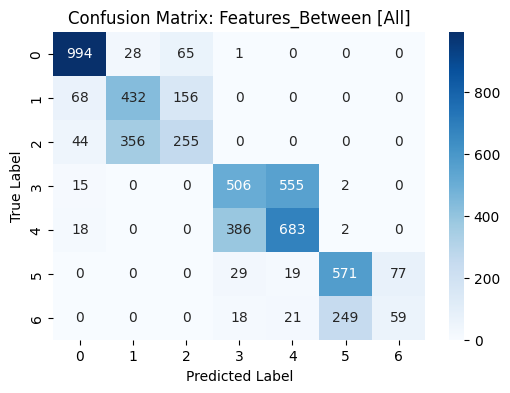


EVALUATING: Features_Between [PCA]
  > Best K found: 13 (Val Acc: 63.39%)
  > FINAL TEST ACCURACY: 62.06%
------------------------------
              precision    recall  f1-score   support

           1     0.8591    0.9246    0.8907      1088
           2     0.5314    0.6570    0.5876       656
           3     0.5167    0.3542    0.4203       655
           4     0.5447    0.4805    0.5106      1078
           5     0.5391    0.6272    0.5798      1089
           6     0.6854    0.8046    0.7403       696
           7     0.3566    0.1470    0.2082       347

    accuracy                         0.6206      5609
   macro avg     0.5762    0.5707    0.5625      5609
weighted avg     0.6056    0.6206    0.6060      5609



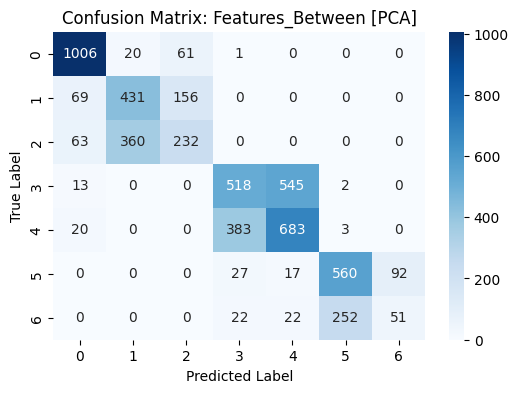


EVALUATING: Features_Between [Selected]
  > Best K found: 13 (Val Acc: 60.30%)
  > FINAL TEST ACCURACY: 59.62%
------------------------------
              precision    recall  f1-score   support

           1     0.8384    0.8392    0.8388      1088
           2     0.5846    0.6845    0.6306       656
           3     0.4868    0.4229    0.4526       655
           4     0.4797    0.5260    0.5018      1078
           5     0.5034    0.5399    0.5210      1089
           6     0.6848    0.7399    0.7113       696
           7     0.4321    0.1009    0.1636       347

    accuracy                         0.5962      5609
   macro avg     0.5728    0.5505    0.5457      5609
weighted avg     0.5895    0.5962    0.5853      5609



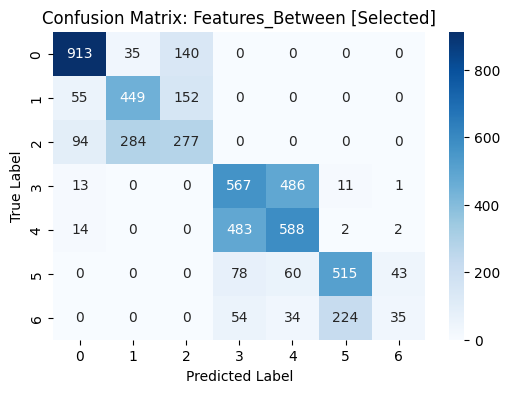


EVALUATING: Embeddings_Between [All]
  > Best K found: 5 (Val Acc: 50.31%)
  > FINAL TEST ACCURACY: 49.83%
------------------------------
              precision    recall  f1-score   support

         1.0     0.7108    0.8173    0.7603      1275
         2.0     0.4034    0.4105    0.4069       687
         3.0     0.3670    0.3178    0.3406       686
         4.0     0.4199    0.4671    0.4423      1111
         5.0     0.4250    0.4511    0.4376      1124
         6.0     0.5767    0.5078    0.5401       703
         7.0     0.2766    0.1077    0.1551       362

    accuracy                         0.4983      5948
   macro avg     0.4542    0.4399    0.4404      5948
weighted avg     0.4850    0.4983    0.4878      5948



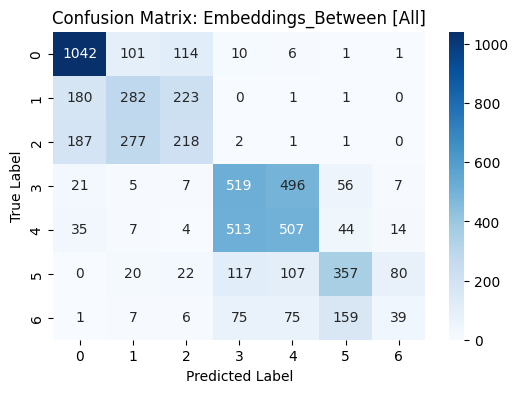


EVALUATING: Embeddings_Between [PCA]
  > Best K found: 11 (Val Acc: 46.29%)
  > FINAL TEST ACCURACY: 48.96%
------------------------------
              precision    recall  f1-score   support

         1.0     0.6999    0.7976    0.7456      1275
         2.0     0.3835    0.4410    0.4103       687
         3.0     0.3491    0.2478    0.2899       686
         4.0     0.4237    0.4770    0.4488      1111
         5.0     0.4418    0.4795    0.4599      1124
         6.0     0.5085    0.4680    0.4874       703
         7.0     0.2400    0.0663    0.1039       362

    accuracy                         0.4896      5948
   macro avg     0.4352    0.4253    0.4208      5948
weighted avg     0.4719    0.4896    0.4753      5948



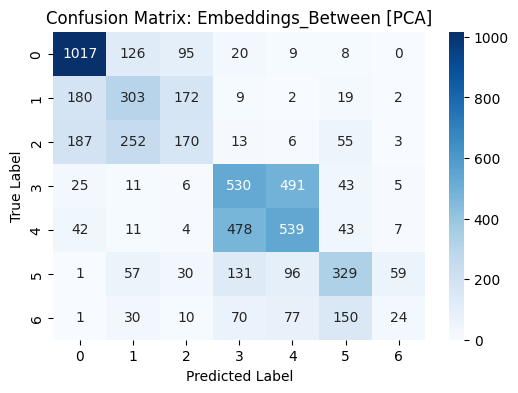


EVALUATING: Embeddings_Between [Selected]
  > Best K found: 3 (Val Acc: 45.99%)
  > FINAL TEST ACCURACY: 47.43%
------------------------------
              precision    recall  f1-score   support

         1.0     0.6882    0.8016    0.7406      1275
         2.0     0.3376    0.6536    0.4452       687
         3.0     0.1667    0.0408    0.0656       686
         4.0     0.4320    0.4914    0.4598      1111
         5.0     0.4602    0.4582    0.4592      1124
         6.0     0.5316    0.3115    0.3928       703
         7.0     0.2471    0.1160    0.1579       362

    accuracy                         0.4743      5948
   macro avg     0.4090    0.4104    0.3887      5948
weighted avg     0.4513    0.4743    0.4464      5948



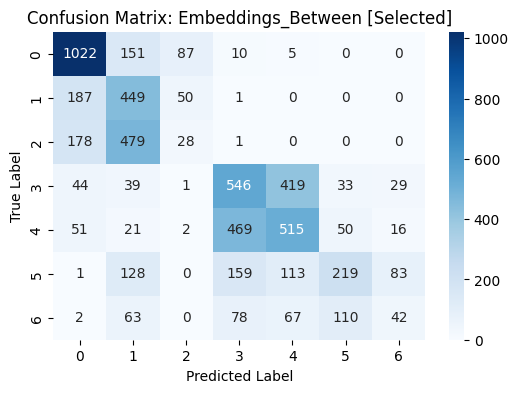


EVALUATING: Features_Within [All]
  > Best K found: 1 (Val Acc: 77.66%)
  > FINAL TEST ACCURACY: 77.92%
------------------------------
              precision    recall  f1-score   support

           1     0.9777    0.9777    0.9777      1168
           2     0.9640    0.9583    0.9611       671
           3     0.9423    0.9603    0.9512       680
           4     0.6289    0.6344    0.6317      1138
           5     0.6355    0.6344    0.6349      1135
           6     0.7345    0.7575    0.7458       734
           7     0.4615    0.4091    0.4337       352

    accuracy                         0.7792      5878
   macro avg     0.7635    0.7617    0.7623      5878
weighted avg     0.7772    0.7792    0.7780      5878



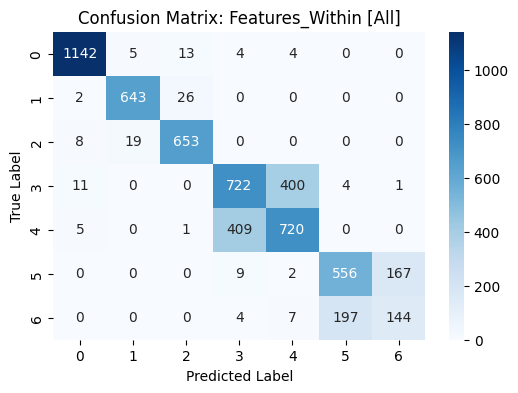


EVALUATING: Features_Within [PCA]
  > Best K found: 1 (Val Acc: 76.60%)
  > FINAL TEST ACCURACY: 77.36%
------------------------------
              precision    recall  f1-score   support

           1     0.9710    0.9735    0.9722      1168
           2     0.9552    0.9523    0.9537       671
           3     0.9352    0.9544    0.9447       680
           4     0.6241    0.6230    0.6236      1138
           5     0.6268    0.6273    0.6270      1135
           6     0.7351    0.7561    0.7455       734
           7     0.4606    0.4148    0.4365       352

    accuracy                         0.7736      5878
   macro avg     0.7583    0.7573    0.7576      5878
weighted avg     0.7714    0.7736    0.7724      5878



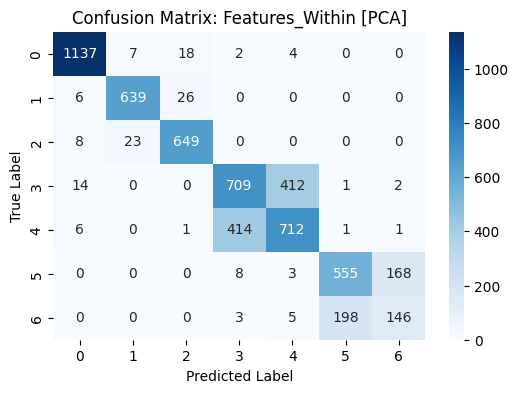


EVALUATING: Features_Within [Selected]
  > Best K found: 7 (Val Acc: 57.44%)
  > FINAL TEST ACCURACY: 58.15%
------------------------------
              precision    recall  f1-score   support

           1     0.6385    0.7560    0.6923      1168
           2     0.5069    0.4933    0.5000       671
           3     0.4744    0.3544    0.4057       680
           4     0.5491    0.5940    0.5707      1138
           5     0.5706    0.5841    0.5773      1135
           6     0.6970    0.7616    0.7279       734
           7     0.4676    0.1847    0.2648       352

    accuracy                         0.5815      5878
   macro avg     0.5577    0.5326    0.5341      5878
weighted avg     0.5711    0.5815    0.5703      5878



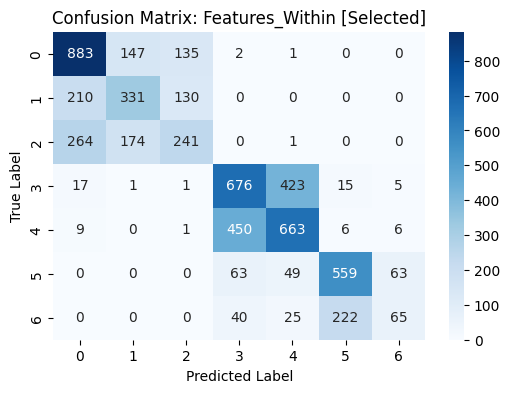


EVALUATING: Embeddings_Within [All]
  > Best K found: 5 (Val Acc: 67.43%)
  > FINAL TEST ACCURACY: 68.98%
------------------------------
              precision    recall  f1-score   support

         1.0     0.8926    0.9440    0.9176      1286
         2.0     0.7224    0.8026    0.7604       684
         3.0     0.7660    0.6999    0.7314       683
         4.0     0.5702    0.6519    0.6083      1109
         5.0     0.5975    0.6007    0.5991      1117
         6.0     0.6119    0.5930    0.6023       710
         7.0     0.3636    0.1239    0.1849       355

    accuracy                         0.6898      5944
   macro avg     0.6463    0.6309    0.6291      5944
weighted avg     0.6778    0.6898    0.6791      5944



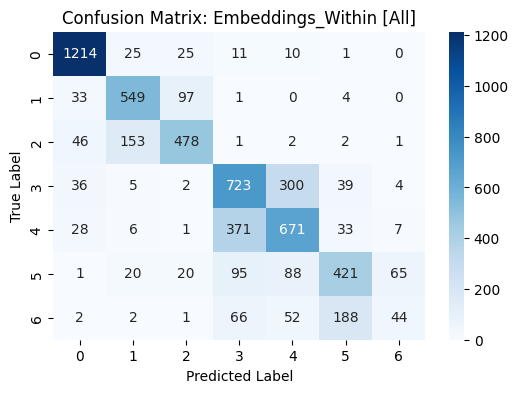


EVALUATING: Embeddings_Within [PCA]
  > Best K found: 13 (Val Acc: 62.84%)
  > FINAL TEST ACCURACY: 62.57%
------------------------------
              precision    recall  f1-score   support

         1.0     0.8463    0.9121    0.8780      1286
         2.0     0.6289    0.7135    0.6685       684
         3.0     0.7093    0.6574    0.6824       683
         4.0     0.5034    0.5942    0.5451      1109
         5.0     0.5283    0.4924    0.5097      1117
         6.0     0.5297    0.5394    0.5345       710
         7.0     0.2237    0.0479    0.0789       355

    accuracy                         0.6257      5944
   macro avg     0.5671    0.5653    0.5567      5944
weighted avg     0.6068    0.6257    0.6113      5944



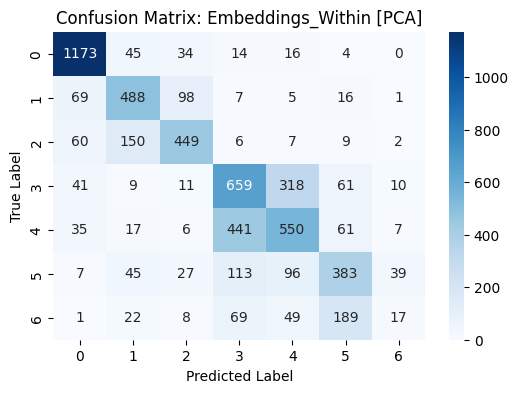


EVALUATING: Embeddings_Within [Selected]
  > Best K found: 11 (Val Acc: 60.13%)
  > FINAL TEST ACCURACY: 60.80%
------------------------------
              precision    recall  f1-score   support

         1.0     0.8787    0.9238    0.9007      1286
         2.0     0.4508    0.9167    0.6043       684
         3.0     0.8736    0.3338    0.4831       683
         4.0     0.5170    0.5879    0.5502      1109
         5.0     0.5753    0.5094    0.5404      1117
         6.0     0.5307    0.4507    0.4874       710
         7.0     0.3448    0.0845    0.1357       355

    accuracy                         0.6080      5944
   macro avg     0.5958    0.5438    0.5288      5944
weighted avg     0.6309    0.6080    0.5904      5944



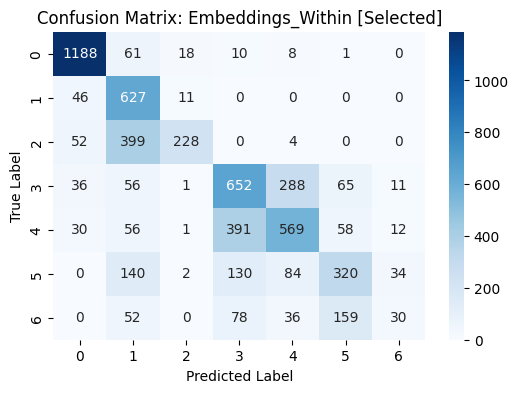


🏆 FINAL LEADERBOARD (Test Accuracy)
Features_Within [All]: 77.92%
Features_Within [PCA]: 77.36%
Embeddings_Within [All]: 68.98%
Embeddings_Within [PCA]: 62.57%
Features_Between [All]: 62.40%
Features_Between [PCA]: 62.06%
Embeddings_Within [Selected]: 60.80%
Features_Between [Selected]: 59.62%
Features_Within [Selected]: 58.15%
Embeddings_Between [All]: 49.83%
Embeddings_Between [PCA]: 48.96%
Embeddings_Between [Selected]: 47.43%


In [28]:
# ==========================================
# 4.1 CUSTOM KNN IMPLEMENTATION
# ==========================================

class CustomKNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        In KNN, 'fitting' just means storing the training data.
        """
        self.X_train = X
        self.y_train = y

    def predict(self, X_test):
        """
        Predicts class for each sample in X_test.
        """
        predictions = []
        
        # Loop through every test sample
        for i in range(len(X_test)):
            test_point = X_test[i]
            # 1. Calculate Euclidean Distances to ALL training points
            distances = np.linalg.norm(self.X_train - test_point, axis=1)
            
            # 2. Get Indices of the k nearest neighbors
            nearest_indices = np.argsort(distances)[:self.k]
            
            # 3. Get the Labels of those neighbors
            nearest_labels = self.y_train[nearest_indices]
            
            # 4. Majority Vote (Mode)
            vote = Counter(nearest_labels).most_common(1)[0][0]
            predictions.append(vote)
        return np.array(predictions)
    
# ==========================================
# SCIKIT-LEARN KNN EVALUATOR
# ==========================================
    
def evaluate_with_sklearn_knn(scenario_data, name="Model"):
    """
    1. Tuning: Finds best k using Train/Val.
    2. Retraining: Fits best k on Train+Val.
    3. Testing: Evaluates on Test.
    """
    print(f"\n{'='*60}")
    print(f"EVALUATING: {name}")
    print(f"{'='*60}")
    
    # 1. Unpack Data
    X_train, y_train = scenario_data['Train']
    X_val, y_val     = scenario_data['Val']
    X_test, y_test   = scenario_data['Test']
    
    # 2. Hyperparameter Tuning (Find Best K)
    # --------------------------------------
    best_k = 1
    best_val_acc = 0
    k_options = [1, 3, 5, 7, 9, 11, 13, 15]
    
    for k in k_options:
        knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        knn.fit(X_train, y_train)
        val_acc = knn.score(X_val, y_val)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_k = k
            
    print(f"  > Best K found: {best_k} (Val Acc: {best_val_acc:.2%})")
    
    # 3. Final Training (Train + Val)
    # -------------------------------
    X_final_train = np.vstack((X_train, X_val))
    y_final_train = np.concatenate((y_train, y_val))
    final_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
    final_model.fit(X_final_train, y_final_train)
    
    # 4. Final Evaluation (Test Set)
    # ------------------------------
    y_pred = final_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"  > FINAL TEST ACCURACY: {test_acc:.2%}")
    print("-" * 30)
    print(classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    return test_acc

# ==========================================
# EXECUTION: RUN ON ALL PREPARED DATA
# ==========================================
# We loop through the 'final_data' dictionary from Step 3.4
# Structure: final_data['Features_Between']['PCA'] -> {'Train':...}

if 'final_data' in locals():
    results_summary = {}
    
    for dataset_name, transformations in final_data.items():
        for transform_name, data_splits in transformations.items():
            run_name = f"{dataset_name} [{transform_name}]"
            # Run Evaluation
            acc = evaluate_with_sklearn_knn(data_splits, run_name)
            # Store result
            results_summary[run_name] = acc

    # Print Final Leaderboard
    print("\n" + "="*40)
    print("🏆 FINAL LEADERBOARD (Test Accuracy)")
    print("="*40)
    # Sort by accuracy descending
    sorted_results = sorted(results_summary.items(), key=lambda x: x[1], reverse=True)
    for name, score in sorted_results:
        print(f"{name}: {score:.2%}")
else:
    print("Error: 'final_data' dictionary not found. Please run Step 3.4 code first.")


Proceeding to 4.2 necessary metrics function 

In [29]:
# ==========================================
# 4.2 METRICS FUNCTION
# ==========================================
def calculate_classification_metrics(y_true, y_pred, model_name="Model"):
    """
    Receives true and predicted labels.
    Returns a dictionary of metrics and plots the Confusion Matrix.
    """
    print(f"\n--- Metrics for: {model_name} ---")
    
    # 1. Calculate Scalar Metrics
    # 'weighted' accounts for class imbalance
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"  > Accuracy:  {acc:.2%}")
    print(f"  > Precision: {prec:.2%}")
    print(f"  > Recall:    {rec:.2%}")
    print(f"  > F1 Score:  {f1:.2%}")

    # 2. Detailed Classification Report
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    
    # 3. Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=sorted(set(y_true)),yticklabels=sorted(set(y_true)))
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('True Activity')
    plt.xlabel('Predicted Activity')
    plt.show()
    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "Confusion Matrix": cm
    }

# ==========================================
# TEST EXAMPLE
# ==========================================
if 'y_test' in locals() and 'y_pred' in locals():
    _ = calculate_classification_metrics(y_test, y_pred, "Test Run")

Train , Test, Evaluate


------------------------------------------------------------
EVALUATING: Features_Between - All
------------------------------------------------------------
  > Best K selected: 15 (Val Acc: 65.03%)
  > FINAL TEST ACCURACY (Retrained): 62.40%

------------------------------------------------------------
EVALUATING: Features_Between - PCA
------------------------------------------------------------
  > Best K selected: 21 (Val Acc: 63.53%)
  > FINAL TEST ACCURACY (Retrained): 62.81%

------------------------------------------------------------
EVALUATING: Features_Between - Selected
------------------------------------------------------------
  > Best K selected: 19 (Val Acc: 59.37%)
  > FINAL TEST ACCURACY (Retrained): 58.05%

------------------------------------------------------------
EVALUATING: Embeddings_Between - All
------------------------------------------------------------
  > Best K selected: 5 (Val Acc: 50.31%)
  > FINAL TEST ACCURACY (Retrained): 49.83%

-----------------

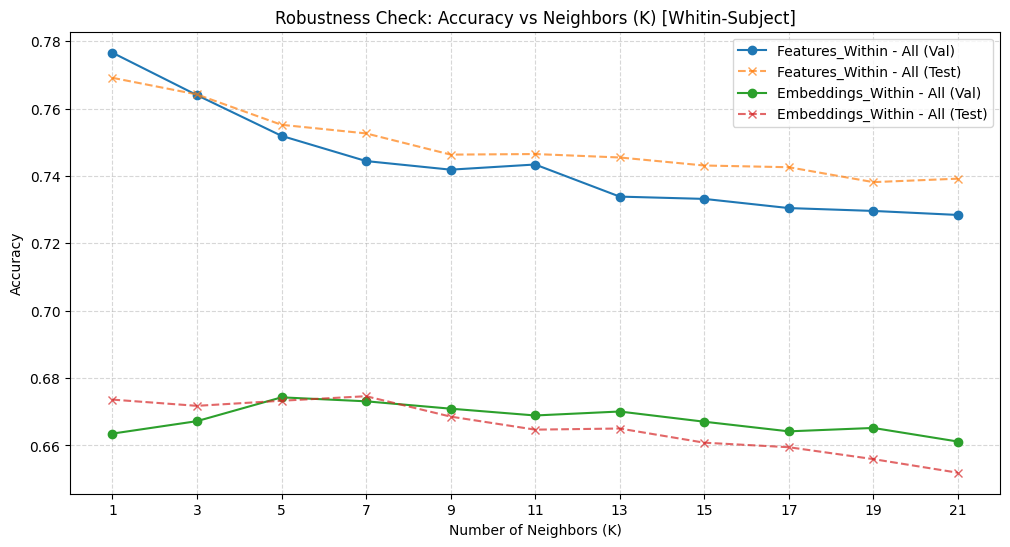

In [ ]:
# ==========================================
# 5.1 HYPERPARAMETER TUNING (ROBUST VERSION)
# ==========================================
def run_evaluation_pipeline(scenario_data, scenario_name):
    print(f"\n{'-'*60}")
    print(f"EVALUATING: {scenario_name}")
    print(f"{'-'*60}")
    
    # 1. Unpack Data
    X_train, y_train = scenario_data['Train']
    X_val, y_val     = scenario_data['Val']
    X_test, y_test   = scenario_data['Test']
    
    # 2. Sweep all K values to check robustness
    # -----------------------------------------
    best_k = 1
    best_val_score = -1
    
    # We store the history
    history = {
        'k': [],
        'val_acc': [],
        'test_acc': []
    }
    
    k_candidates = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
    
    for k in k_candidates:
        # Train on TRAIN only
        knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        knn.fit(X_train, y_train)
        
        # Evaluate on VAL (Used for selection)
        val_score = knn.score(X_val, y_val)
        
        # Evaluate on TEST
        test_score = knn.score(X_test, y_test)
        
        # Store metrics
        history['k'].append(k)
        history['val_acc'].append(val_score)
        history['test_acc'].append(test_score)
        
        # Selection Logic
        if val_score > best_val_score:
            best_val_score = val_score
            best_k = k
            
    print(f"  > Best K selected: {best_k} (Val Acc: {best_val_score:.2%})")
    
    # 3. Retrain on Full Training Data (Train + Val) for Final Report
    # --------------------------------------------------------------
    # Train on as much data as possible with the best K
    X_final_train = np.vstack((X_train, X_val))
    y_final_train = np.concatenate((y_train, y_val))
    final_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
    final_model.fit(X_final_train, y_final_train)
    
    # 4. Final Test Evaluation
    # ------------------------
    y_pred = final_model.predict(X_test)
    final_test_acc = accuracy_score(y_test, y_pred)
    final_test_f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"  > FINAL TEST ACCURACY (Retrained): {final_test_acc:.2%}")
    
    return {
        "Scenario": scenario_name,
        "Best_K": best_k,
        "Test_Acc": final_test_acc,
        "Test_F1": final_test_f1,
        "History": history
    }

# ==========================================
# EXECUTION & ROBUSTNESS PLOTTING
# ==========================================

all_results = []
metrics_summary = []

if 'final_data' in locals():
    # Loop through all scenarios
    for dataset_key, transformations in final_data.items():
        for transform_key, data_splits in transformations.items():
            
            name = f"{dataset_key} - {transform_key}"
            res = run_evaluation_pipeline(data_splits, name)
            
            all_results.append(res)
            metrics_summary.append({
                "Dataset": dataset_key,
                "Method": transform_key,
                "Best K": res['Best_K'],
                "Test Acc": res['Test_Acc'],
                "Test F1": res['Test_F1']
            })

    # 1. Print Summary Table
    print("\n" + "="*60)
    print("🏆 FINAL RESULTS SUMMARY")
    print("="*60)
    df_results = pd.DataFrame(metrics_summary).sort_values(by="Test Acc", ascending=False)
    pd.options.display.float_format = '{:.2%}'.format
    print(df_results)

    # 2. PLOT ROBUSTNESS (Accuracy vs K)
    print("\n" + "="*60)
    print("📊 ROBUSTNESS ANALYSIS: ACCURACY vs K")
    print("="*60)
    
    # Filter for scenarios (e.g., Between-Subject / PCA)
    plt.figure(figsize=(12, 6))

    for res in all_results:
        if "All" in res['Scenario'] and "Within" in res['Scenario']:
            
            hist = res['History']
            plt.plot(hist['k'], hist['val_acc'], marker='o', label=f"{res['Scenario']} (Val)")
            plt.plot(hist['k'], hist['test_acc'], marker='x', linestyle='--', alpha=0.7, label=f"{res['Scenario']} (Test)")

    plt.title("Robustness Check: Accuracy vs Neighbors (K) [Whitin-Subject]")
    plt.xlabel("Number of Neighbors (K)")
    plt.ylabel("Accuracy")
    plt.xticks(np.arange(1, 22, 2))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()
    
else:
    print("Error: 'final_data' dictionary not found. Please run Step 3.4 first.")

5.3 Hypothis Testing

Starting Statistical Comparison (10 iterations)...
Strategy: Between-Subject Split (Randomized Groups)
  Iter 1: Features=60.67% | Embeddings=45.90%
  Iter 2: Features=62.22% | Embeddings=46.88%
  Iter 3: Features=62.37% | Embeddings=48.86%
  Iter 4: Features=60.04% | Embeddings=48.15%
  Iter 5: Features=60.25% | Embeddings=47.08%
  Iter 6: Features=63.26% | Embeddings=47.64%
  Iter 7: Features=60.23% | Embeddings=46.12%
  Iter 8: Features=64.38% | Embeddings=49.42%
  Iter 9: Features=60.94% | Embeddings=44.77%
  Iter 10: Features=62.22% | Embeddings=46.88%

RESULTS OF HYPOTHESIS TESTING
Mean Accuracy (Features):   61.66%
Mean Accuracy (Embeddings): 47.17%

[Test 1] ANOVA:
  > F-Statistic: 510.4076
  > P-Value:     0.00000
  >> Significant Difference (Data means are likely different)

[Test 2] Kruskal-Wallis:
  > H-Statistic: 14.3072
  > P-Value:     0.00016
  >> Significant Difference (Data distributions are different)


C:\Users\ramya\AppData\Local\Temp\ipykernel_82980\2372336807.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_res, x='Model', y='Accuracy', palette="Set2")


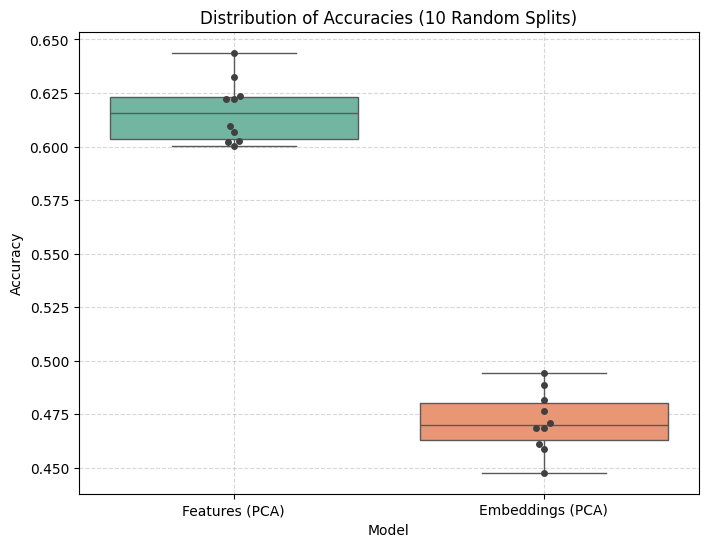

In [32]:
# ==========================================
# 5.3 HYPOTHESIS TESTING (KRUSKAL-WALLIS)
# ==========================================
def run_comparative_hypothesis_testing(df_feat, df_emb, n_iterations=10):
    """
    Repeatedly splits data, trains both models, and collects accuracies.
    Performs ANOVA and Kruskal-Wallis tests.
    """
    print(f"Starting Statistical Comparison ({n_iterations} iterations)...")
    print("Strategy: Between-Subject Split (Randomized Groups)")
    
    scores_feat = []
    scores_emb = []
    
    # Get list of all participants
    participants = df_feat["Participant"].unique()
    
    for i in range(n_iterations):
        # 1. Randomize Split (9 Train / 3 Val / 3 Test)
        np.random.shuffle(participants)
        train_ids = participants[:9]
        test_ids = participants[9:]
        
        # extract data
        def get_data(df):
            train = df[df["Participant"].isin(train_ids)]
            test = df[df["Participant"].isin(test_ids)]
            
            X_train = train.drop(columns=["Activity", "Participant", "Participant_Activity"], errors='ignore').values
            y_train = train["Activity"].values
            X_test = test.drop(columns=["Activity", "Participant", "Participant_Activity"], errors='ignore').values
            y_test = test["Activity"].values
            return X_train, y_train, X_test, y_test

        # -----------------------------------
        # MODEL A: FEATURES (PCA)
        # -----------------------------------
        X_tr_f, y_tr_f, X_te_f, y_te_f = get_data(df_feat)
        
        scaler_f = StandardScaler().fit(X_tr_f)
        X_tr_f_sc = scaler_f.transform(X_tr_f)
        X_te_f_sc = scaler_f.transform(X_te_f)
        
        pca_f = PCA(n_components=0.90).fit(X_tr_f_sc)
        X_tr_f_pca = pca_f.transform(X_tr_f_sc)
        X_te_f_pca = pca_f.transform(X_te_f_sc)
        
        # Use K=21 (from your results)
        knn_f = KNeighborsClassifier(n_neighbors=21, n_jobs=-1)
        knn_f.fit(X_tr_f_pca, y_tr_f)
        acc_f = knn_f.score(X_te_f_pca, y_te_f)
        scores_feat.append(acc_f)
        
        # -----------------------------------
        # MODEL B: EMBEDDINGS (PCA)
        # -----------------------------------
        X_tr_e, y_tr_e, X_te_e, y_te_e = get_data(df_emb)
        
        scaler_e = StandardScaler().fit(X_tr_e)
        X_tr_e_sc = scaler_e.transform(X_tr_e)
        X_te_e_sc = scaler_e.transform(X_te_e)
        
        pca_e = PCA(n_components=0.90).fit(X_tr_e_sc)
        X_tr_e_pca = pca_e.transform(X_tr_e_sc)
        X_te_e_pca = pca_e.transform(X_te_e_sc)
        
        # Use K=21 (from your results)
        knn_e = KNeighborsClassifier(n_neighbors=21, n_jobs=-1)
        knn_e.fit(X_tr_e_pca, y_tr_e)
        acc_e = knn_e.score(X_te_e_pca, y_te_e)
        scores_emb.append(acc_e)
        print(f"  Iter {i+1}: Features={acc_f:.2%} | Embeddings={acc_e:.2%}")

    # ==========================================
    # 2. STATISTICAL TESTS
    # ==========================================
    print("\n" + "="*40)
    print("RESULTS OF HYPOTHESIS TESTING")
    print("="*40)
    print(f"Mean Accuracy (Features):   {np.mean(scores_feat):.2%}")
    print(f"Mean Accuracy (Embeddings): {np.mean(scores_emb):.2%}")
    
    # TEST 1: ANOVA (One-way)
    # -----------------------
    f_stat, p_anova = stats.f_oneway(scores_feat, scores_emb)
    print(f"\n[Test 1] ANOVA:")
    print(f"  > F-Statistic: {f_stat:.4f}")
    print(f"  > P-Value:     {p_anova:.5f}")
    if p_anova < 0.05: print("  >> Significant Difference (Data means are likely different)")
    else: print("  >> No Significant Difference")

    # TEST 2: KRUSKAL-WALLIS (Non-Parametric)
    # ---------------------------------------
    h_stat, p_kruskal = stats.kruskal(scores_feat, scores_emb)
    print(f"\n[Test 2] Kruskal-Wallis:")
    print(f"  > H-Statistic: {h_stat:.4f}")
    print(f"  > P-Value:     {p_kruskal:.5f}")
    if p_kruskal < 0.05: print("  >> Significant Difference (Data distributions are different)")
    else: print("  >> No Significant Difference")
    
    # ==========================================
    # 3. VISUALIZATION
    # ==========================================
    # Prepare DataFrame for Seaborn
    df_res = pd.DataFrame({
        'Accuracy': scores_feat + scores_emb,
        'Model': ['Features (PCA)'] * n_iterations + ['Embeddings (PCA)'] * n_iterations
    })
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_res, x='Model', y='Accuracy', palette="Set2")
    sns.swarmplot(data=df_res, x='Model', y='Accuracy', color=".25")
    plt.title(f"Distribution of Accuracies ({n_iterations} Random Splits)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
if 'FEATURES_DATASET' in locals() and 'EMBEDDINGS_DATASET' in locals():
    run_comparative_hypothesis_testing(FEATURES_DATASET, EMBEDDINGS_DATASET, n_iterations=10)
else:
    print("Error: Datasets not found.")

Deployment

In [31]:

# ==========================================
# 1. SETUP: SAVE THE BEST MODEL
# ==========================================
# 'Features_Within - All' as the "Best Model".

if 'final_data' in locals():
    # 1. Get the Training Data for the best scenario
    best_scenario_data = final_data['Features_Within']['All']['Train']
    X_train, y_train = best_scenario_data
    
    # 2. Fit the Scaler (Normalization)
    deploy_scaler = StandardScaler()
    deploy_scaler.fit(X_train)
    # grab the RAW training set to fit the scaler properly for deployment
    if 'X_train_f' in locals():
        raw_X_train = X_train_f.drop(columns=["Activity", "Participant", "Participant_Activity"], errors='ignore')
        deploy_scaler = StandardScaler()
        deploy_scaler.fit(raw_X_train)
        
        # 3. Train the Classifier
        #melhor k=1
        deploy_model = KNeighborsClassifier(n_neighbors=1)
        
        # train on the scaled version of the raw data
        X_train_scaled = deploy_scaler.transform(raw_X_train)
        deploy_model.fit(X_train_scaled, X_train_f["Activity"])
        
        print("Deployment Model Trained & Ready: Features (KNN k=1)")
    else:
        print("Error: Original split 'X_train_f' not found. Cannot retrain for deployment.")
else:
    print("Error: 'final_data' not found.")


# ==========================================
# 2. DEPLOYMENT FUNCTION
# ==========================================

def classify_segment(segment_data, model_type='features'):
    """
    Input: numpy array of shape (256, 9) [AccX, AccY, AccZ, GyrX, GyrY, GyrZ, MagX, MagY, MagZ]
    Returns: Predicted Activity (int)
    """
    if segment_data.shape != (256, 9):
        print(f"Warning: Expected (256, 9), got {segment_data.shape}. Resizing/Slicing might occur.")
    
    # ---------------------------------------
    # PATH A: MANUAL FEATURES (Best Performance)
    # ---------------------------------------
    if model_type == 'features':
        # 1. Feature Extraction
        # 256 samples usually implies ~5 seconds at ~50Hz.
        estimated_fs = 50.0
        # Extract features
        features_1d = extract_feature_vector(segment_data, estimated_fs)
        # Reshape to (1, n_features) for sklearn
        features_2d = features_1d.reshape(1, -1)
        # 2. Normalization
        features_scaled = deploy_scaler.transform(features_2d)
        # 3. Classification
        prediction = deploy_model.predict(features_scaled)
        return prediction[0]

    # ---------------------------------------
    # PATH B: EMBEDDINGS (Deep Learning)
    # ---------------------------------------
    elif model_type == 'embeddings':
        # 1. Preprocessing
        acc_data = segment_data[:, :3]
        # Resample to 30Hz / 150 samples (Required by Harnet5)
        target_len = 150
        t_in = np.linspace(0, 5.0, 256)
        t_target = np.linspace(0, 5.0, target_len)
        
        f = interp1d(t_in, acc_data, axis=0, kind='linear', fill_value="extrapolate")
        acc_resampled = f(t_target).astype(np.float32) # (150, 3)
        
        # 2. Generate Embedding
        tensor_in = torch.from_numpy(acc_resampled).float().unsqueeze(0).permute(0, 2, 1)
        
        # Load model (cached if possible)
        encoder, device = load_harnet_model()
        tensor_in = tensor_in.to(device)
        
        with torch.no_grad():
            embedding = encoder(tensor_in).cpu().numpy()
            
        if embedding.ndim > 2:
            embedding = embedding.reshape(1, -1)
            
        # Note: You would need a separate scaler/model trained on Embeddings to use this path.
        # returning raw embedding for demonstration
        return "Embedding generated (Model not loaded)"

# ==========================================
# 3. TEST THE FUNCTION
# ==========================================
# shape (256 samples, 9 sensors)
dummy_input = np.random.normal(0, 1, (256, 9))

# Run Classification
try:
    pred_label = classify_segment(dummy_input, model_type='features')
    print(f"\nPredicted Activity for random noise: {pred_label}")
    
    # If you want to test with REAL data:
    real_segment = df_all_raw.iloc[0:256, 1:10].values
    pred_real = classify_segment(real_segment)
    print(f"Predicted Activity for real sample: {pred_real}")
    
except Exception as e:
    print(f"Deployment Error: {e}")

Deployment Model Trained & Ready: Features (KNN k=1)

Predicted Activity for random noise: 6


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted Activity for real sample: 1


c:\Users\ramya\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


7.1 Applying SMOTE to the best performance model in order to check if balancing the classes in the data set have an impact in producing better results


BONUS TASK: BALANCING THE BEST MODEL (SMOTE)
Selected Scenario: Features_Within - All
Original Training Shape: (17632, 144)

--- Class Distribution (Before SMOTE) ---
  Activity 1: 3486 samples
  Activity 2: 2022 samples
  Activity 3: 2049 samples
  Activity 4: 3406 samples
  Activity 5: 3399 samples
  Activity 6: 2198 samples
  Activity 7: 1072 samples

Applying SMOTE to Training Data...
New Training Shape: (24402, 144)
--- Class Distribution (After SMOTE) ---
  Activity 1: 3486 samples
  Activity 2: 3486 samples
  Activity 3: 3486 samples
  Activity 4: 3486 samples
  Activity 5: 3486 samples
  Activity 6: 3486 samples
  Activity 7: 3486 samples

----------------------------------------
RESULTS COMPARISON
----------------------------------------
Original Accuracy: 76.91%
Balanced Accuracy: 76.61%
>> CHANGE: -0.31% (SMOTE might have introduced noise)

Detailed Report (Balanced Model):
              precision    recall  f1-score   support

           1     0.9760    0.9769    0.9765   

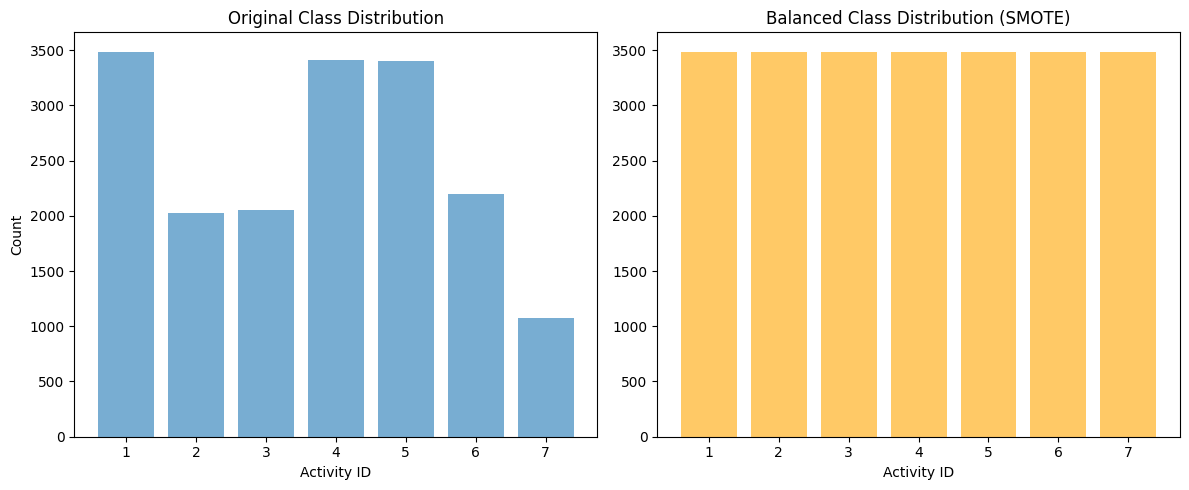

In [ ]:
# ==========================================
# 7.1 BONUS: IMPROVING WITH CLASS BALANCING
# ==========================================

def evaluate_with_smote_improvement(final_data_dict):
    print("\n" + "="*60)
    print("BONUS TASK: BALANCING THE BEST MODEL (SMOTE)")
    print("="*60)
    
    # 1. Select the Best Model's Data
    if 'Features_Within' in final_data_dict and 'All' in final_data_dict['Features_Within']:
        best_scenario = final_data_dict['Features_Within']['All']
        scenario_name = "Features_Within - All"
    else:
        print("Error: Best scenario 'Features_Within - All' not found.")
        return

    X_train, y_train = best_scenario['Train']
    X_test, y_test   = best_scenario['Test']
    
    print(f"Selected Scenario: {scenario_name}")
    print(f"Original Training Shape: {X_train.shape}")
    
    # 2. Check Class Distribution (Before)
    print("\n--- Class Distribution (Before SMOTE) ---")
    counter_before = Counter(y_train)
    for k, v in sorted(counter_before.items()):
        print(f"  Activity {k}: {v} samples")
        
    # 3. Apply SMOTE
    # --------------------------------
    print("\nApplying SMOTE to Training Data...")
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    print(f"New Training Shape: {X_train_bal.shape}")
    print("--- Class Distribution (After SMOTE) ---")
    counter_after = Counter(y_train_bal)
    for k, v in sorted(counter_after.items()):
        print(f"  Activity {k}: {v} samples")
        
    # 4. Train & Evaluate (Balanced vs Original)
    # ------------------------------------------
    k_best = 1
    
    # A. Train on Balanced Data
    knn_bal = KNeighborsClassifier(n_neighbors=k_best, n_jobs=-1)
    knn_bal.fit(X_train_bal, y_train_bal)
    y_pred_bal = knn_bal.predict(X_test)
    acc_bal = accuracy_score(y_test, y_pred_bal)
    
    # B. Compare with Original (Unbalanced)
    knn_orig = KNeighborsClassifier(n_neighbors=k_best, n_jobs=-1)
    knn_orig.fit(X_train, y_train)
    y_pred_orig = knn_orig.predict(X_test)
    acc_orig = accuracy_score(y_test, y_pred_orig)
    
    print("\n" + "-"*40)
    print("RESULTS COMPARISON")
    print("-" * 40)
    print(f"Original Accuracy: {acc_orig:.2%}")
    print(f"Balanced Accuracy: {acc_bal:.2%}")
    diff = acc_bal - acc_orig
    
    if diff > 0:
        print(f">> IMPROVEMENT: +{diff:.2%} 🚀")
    else:
        print(f">> CHANGE: {diff:.2%} (SMOTE might have introduced noise)")
        
    print("\nDetailed Report (Balanced Model):")
    print(classification_report(y_test, y_pred_bal, digits=4))
    
    # 5. Visualization of Effect
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot Counts
    labels = sorted(counter_before.keys())
    orig_counts = [counter_before[l] for l in labels]
    new_counts = [counter_after[l] for l in labels]
    ax[0].bar(labels, orig_counts, alpha=0.6, label='Original')
    ax[0].set_title("Original Class Distribution")
    ax[0].set_xlabel("Activity ID")
    ax[0].set_ylabel("Count")
    ax[1].bar(labels, new_counts, color='orange', alpha=0.6, label='Balanced')
    ax[1].set_title("Balanced Class Distribution (SMOTE)")
    ax[1].set_xlabel("Activity ID")
    
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================

if 'final_data' in locals():
    evaluate_with_smote_improvement(final_data)
else:
    print("Error: 'final_data' not found. Please run Step 3.4 first.")